In [1]:
import pandapower as pp
import pandapower.plotting as plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import grid_plotting as gp

from helper_function import (
    compute_admittance_matrix,
    compute_power_injections,
    build_jacobian,
    power_mismatch,
    newton_raphson_power_flow,
)
from network_5bus import create_5bus_network

importlib.reload(gp)

<module 'grid_plotting' from '/home/agerami/github/python_installation_and_tutorials/tutorials/to_go_further/grid_plotting.py'>

In [2]:
# manual line data in per unit
line_pu = pd.DataFrame({
    "from_bus": [1, 2, 1, 3, 2, 4],
    "to_bus":   [2, 3, 3, 4, 4, 5],
    "r_pu":     [0.02, 0.02, 0.02, 0.04, 0.04, 0.00],
    "x_pu":     [0.20, 0.40, 0.40, 0.40, 0.40, 0.05],
    "b_pu":     [0.80, 0.80, 0.40, 0.40, 0.40, 0.00]
})

Ybus_manual, bus_map = compute_admittance_matrix(line_pu)


print("Manual Ybus:")
print(Ybus_manual)

Manual Ybus:
[[ 0.61973778 -6.84426064j -0.4950495  +4.95049505j
  -0.12468828 +2.49376559j  0.         +0.j
   0.         +0.j        ]
 [-0.4950495  +4.95049505j  0.86726254 -8.91950816j
  -0.12468828 +2.49376559j -0.24752475 +2.47524752j
   0.         +0.j        ]
 [-0.12468828 +2.49376559j -0.12468828 +2.49376559j
   0.49690131 -6.6627787j  -0.24752475 +2.47524752j
   0.         +0.j        ]
 [ 0.         +0.j         -0.24752475 +2.47524752j
  -0.24752475 +2.47524752j  0.4950495 -24.55049505j
   0.        +20.j        ]
 [ 0.         +0.j          0.         +0.j
   0.         +0.j          0.        +20.j
   0.        -20.j        ]]


In [3]:
net = create_5bus_network()

print(net.bus[["name", "vn_kv"]])
print(net.line[["name", "from_bus", "to_bus"]])
print(net.gen[["name", "bus"]])
print(net.load[["name", "bus"]])

    name  vn_kv
0  Bus 1  400.0
1  Bus 2  400.0
2  Bus 3  400.0
3  Bus 4  400.0
4  Bus 5   20.0
     name  from_bus  to_bus
0  Line A         0       1
1  Line B         1       2
2  Line C         0       2
3  Line D         2       3
4  Line E         1       3
                 name  bus
0  PV Generator Bus 2    1
1  PV Generator Bus 5    4
         name  bus
0  Load Bus 2    1
1  Load Bus 3    2


In [4]:
bus_idx = dict(zip(net.bus["name"], net.bus.index))

b1 = bus_idx["Bus 1"]
b2 = bus_idx["Bus 2"]
b3 = bus_idx["Bus 3"]
b4 = bus_idx["Bus 4"]
b5 = bus_idx["Bus 5"]

In [5]:
# bus positions
pos = {
    b1: (0.6, 2.9),
    b2: (3.0, 4.0),
    b3: (3.0, 1.8),
    b4: (5.8, 2.9),
    b5: (8.4, 2.9),
}

In [6]:
bus_label_offset = {
    b1: (-0.1, -0.35),
    b2: (0.10, 0.25),
    b3: (0.10, -0.25),
    b4: (0.10, 0.15),
    b5: (0.10, 0.15),
}

line_label_offset = {
    "Line A": (-0.55, 0.05),
    "Line B": (0.15, 0.05),
    "Line C": (-0.70, -0.45),
    "Line D": (0.20, -0.45),
    "Line E": (0.25, 0.05),
}

gen_label_offset = {
    "PV Generator Bus 2": (-0.45, 1.00),
    "PV Generator Bus 5": (-0.45, 1.00),
}

load_label_offset = {
    "Load Bus 2": (-0.95, -0.75),
    "Load Bus 3": (-0.55, -1.10),
}

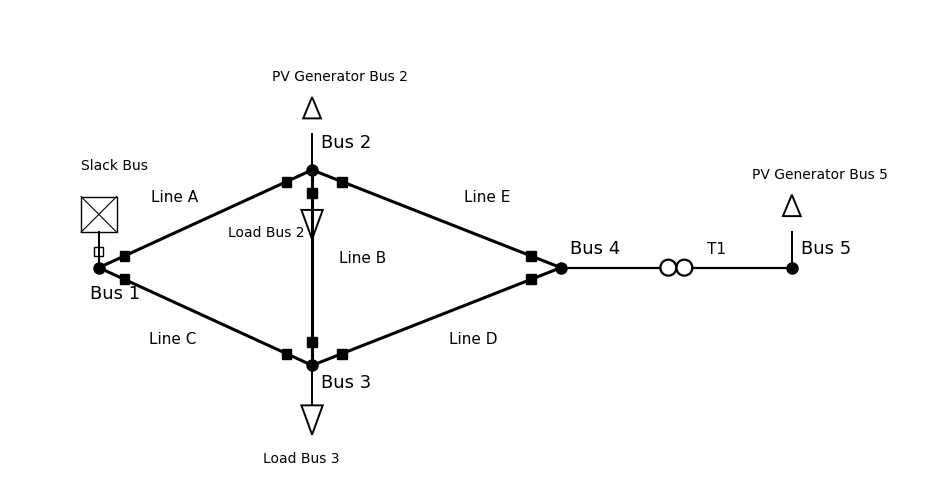

In [7]:
fig, ax = gp.plot_pandapower_line_style(
    net,
    pos,
    bus_label_offset=bus_label_offset,
    line_label_offset=line_label_offset,
    gen_label_offset=gen_label_offset,
    load_label_offset=load_label_offset,
    figsize=(12, 6),
)

plt.show()

In [8]:

n_bus = len(net.bus)

# slack bus from ext_grid
slack_buses = sorted(net.ext_grid["bus"].astype(int).unique().tolist())
slack_bus = slack_buses[0]

# PV buses from generators
pv_buses = sorted(set(net.gen["bus"].astype(int).tolist()))

# PQ buses = all buses except slack and PV
all_buses = set(range(n_bus))
pq_buses = sorted(all_buses - {slack_bus} - set(pv_buses))

print("\nBus types:")
print("slack_bus =", slack_bus)
print("pv_buses  =", pv_buses)
print("pq_buses  =", pq_buses)


Bus types:
slack_bus = 0
pv_buses  = [1, 4]
pq_buses  = [2, 3]


In [9]:
# Build powers directly from pandapower net
# P_net = P_gen - P_load
# Q_net = Q_gen - Q_load

P_net_mw = np.zeros(n_bus)
Q_net_mvar = np.zeros(n_bus)

# generators contribute positive active power
for _, row in net.gen.iterrows():
    bus = int(row.bus)
    P_net_mw[bus] += float(row.p_mw)

# loads consume power -> subtract
for _, row in net.load.iterrows():
    bus = int(row.bus)
    P_net_mw[bus] -= float(row.p_mw)
    Q_net_mvar[bus] -= float(row.q_mvar)

# if you later use sgen, add this:
if hasattr(net, "sgen") and len(net.sgen) > 0:
    for _, row in net.sgen.iterrows():
        bus = int(row.bus)
        P_net_mw[bus] += float(row.p_mw)
        Q_net_mvar[bus] += float(row.q_mvar)

# convert to pu
P_net = P_net_mw / net.sn_mva
Q_net = Q_net_mvar / net.sn_mva

print("\n powers:")
print("P_net (MW)   =", P_net_mw)
print("Q_net (Mvar) =", Q_net_mvar)
print("P_net (pu)   =", np.round(P_net, 4))
print("Q_net (pu)   =", np.round(Q_net, 4))


 powers:
P_net (MW)   = [   0.   50. -200.    0.  100.]
Q_net (Mvar) = [  0. -20. -80.   0.   0.]
P_net (pu)   = [ 0.   0.5 -2.   0.   1. ]
Q_net (pu)   = [ 0.  -0.2 -0.8  0.   0. ]


In [10]:
# extract the newton-raphson results from helper_function 

Vm_init = np.ones(n_bus, dtype=float)
Va_init_deg = np.zeros(n_bus, dtype=float)

# Slack voltage from ext_grid
Vm_init[slack_bus] = float(net.ext_grid.iloc[0].vm_pu)

# PV bus voltages from generators
for _, row in net.gen.iterrows():
    Vm_init[int(row.bus)] = float(row.vm_pu)

print("\nInitial guess:")
print("Vm_init     =", np.round(Vm_init, 4))
print("Va_init_deg =", np.round(Va_init_deg, 4))

Vm_nr, Va_nr, n_iter = newton_raphson_power_flow(
    Ybus=Ybus_manual,
    P_net=P_net,
    Q_net=Q_net,
    slack_bus=slack_bus,
    pv_buses=pv_buses,
    pq_buses=pq_buses,
    Vm_init=Vm_init,
    Va_init_deg=Va_init_deg,
    tol=1e-8,
    max_iter=20
)

print("\nManual Newton-Raphson results:")
print("Iterations =", n_iter)
print("Vm_NR =", np.round(Vm_nr, 4))
print("Va_NR =", np.round(Va_nr, 4))


Initial guess:
Vm_init     = [1.   1.05 1.   1.   1.  ]
Va_init_deg = [0. 0. 0. 0. 0.]
Iteration 1: max mismatch = 1.99e+00
Iteration 2: max mismatch = 2.73e-01
Iteration 3: max mismatch = 1.66e-02
Iteration 4: max mismatch = 9.69e-05
Iteration 5: max mismatch = 4.24e-09
Convergence achieved!

Manual Newton-Raphson results:
Iterations = 4
Vm_NR = [1.     1.05   0.9512 1.0138 1.    ]
Va_NR = [  0.       0.2631 -14.2978   4.685    7.5119]


In [11]:
# run power flow
pp.runpp(net)

Vm_pp = net.res_bus["vm_pu"].values
Va_pp = net.res_bus["va_degree"].values
S_base = net.sn_mva

print("\nPandapower results:")
print("Vm_PP =", np.round(Vm_pp, 4))
print("Va_PP =", np.round(Va_pp, 4))


Pandapower results:
Vm_PP = [1.     1.05   0.9512 1.0138 1.    ]
Va_PP = [  0.       0.2631 -14.2978   4.685    7.5119]


In [12]:
# compare NR and PP results

comparison = pd.DataFrame({
    "bus_index": net.bus.index.astype(int),
    "bus_name": net.bus["name"].values,
    "Vm_NR": np.round(Vm_nr, 4),
    "Vm_PP": np.round(Vm_pp, 4),
    "dVm": np.round(Vm_nr - Vm_pp, 6),
    "Va_NR (deg)": np.round(Va_nr, 4),
    "Va_PP (deg)": np.round(Va_pp, 4),
    "dVa (deg)": np.round(Va_nr - Va_pp, 6),
})

print("\nComparison: NR vs PP results:")
print(comparison.to_string(index=False))


Comparison: NR vs PP results:
 bus_index bus_name  Vm_NR  Vm_PP  dVm  Va_NR (deg)  Va_PP (deg)  dVa (deg)
         0    Bus 1 1.0000 1.0000  0.0       0.0000       0.0000        0.0
         1    Bus 2 1.0500 1.0500  0.0       0.2631       0.2631        0.0
         2    Bus 3 0.9512 0.9512  0.0     -14.2978     -14.2978        0.0
         3    Bus 4 1.0138 1.0138  0.0       4.6850       4.6850        0.0
         4    Bus 5 1.0000 1.0000  0.0       7.5119       7.5119        0.0


In [13]:
# Compute power injections from Ybus using pandapower voltages

P_inj_pu, Q_inj_pu = compute_power_injections(Ybus_manual, Vm_pp, Va_pp)

P_inj_MW = P_inj_pu * S_base
Q_inj_Mvar = Q_inj_pu * S_base

inj_results = pd.DataFrame({
    "bus_index": net.bus.index.astype(int),
    "bus_name": net.bus["name"].values,
    "Vm (pu)": np.round(Vm_pp, 3),
    "Va (deg)": np.round(Va_pp, 3),
    "P_inj (MW)": np.round(P_inj_MW, 2),
    "Q_inj (Mvar)": np.round(Q_inj_Mvar, 2)
})

print("\nPower injections from Ybus formulas using pandapower voltages:")
print(inj_results.to_string(index=False))


Power injections from Ybus formulas using pandapower voltages:
 bus_index bus_name  Vm (pu)  Va (deg)  P_inj (MW)  Q_inj (Mvar)
         0    Bus 1    1.000     0.000       54.69        -67.91
         1    Bus 2    1.050     0.263       50.00        -41.53
         2    Bus 3    0.951   -14.298     -200.00        -80.00
         3    Bus 4    1.014     4.685        0.00          0.00
         4    Bus 5    1.000     7.512      100.00        -25.18


In [14]:
# reconstruct generator powers

Pload = np.zeros(n_bus)
Qload = np.zeros(n_bus)

for _, row in net.load.iterrows():
    bus = int(row.bus)
    Pload[bus] += float(row.p_mw)
    Qload[bus] += float(row.q_mvar)
    
Pgen = P_inj_MW + Pload
Qgen = Q_inj_Mvar + Qload

gen_buses = np.array([True, True, False, False, True])

Pgen_display = np.where(gen_buses, np.round(Pgen, 2), np.nan)
Qgen_display = np.where(gen_buses, np.round(Qgen, 2), np.nan)

summary = pd.DataFrame({
    "Bus": [1, 2, 3, 4, 5],
    "|V| (pu)": np.round(Vm_pp, 3),
    "Angle (deg)": np.round(Va_pp, 3),
    "Pgen (MW)": Pgen_display,
    "Qgen (Mvar)": Qgen_display,
    "Pload (MW)": Pload,
    "Qload (Mvar)": Qload
})

summary_display = summary.copy().astype(object)
summary_display = summary_display.where(pd.notnull(summary_display), "-")

print(summary_display.to_string(index=False))

Bus |V| (pu) Angle (deg) Pgen (MW) Qgen (Mvar) Pload (MW) Qload (Mvar)
  1      1.0         0.0     54.69      -67.91        0.0          0.0
  2     1.05       0.263     150.0      -21.53      100.0         20.0
  3    0.951     -14.298         -           -      200.0         80.0
  4    1.014       4.685         -           -        0.0          0.0
  5      1.0       7.512     100.0      -25.18        0.0          0.0


In [15]:
total_generation = np.nansum(Pgen_display)
total_load = np.sum(Pload)
total_active_loss = total_generation - total_load

print(f"Total generation = {total_generation:.2f} MW")
print(f"Total load       = {total_load:.2f} MW")
print(f"Total active loss = {total_active_loss:.2f} MW")

Total generation = 304.69 MW
Total load       = 300.00 MW
Total active loss = 4.69 MW


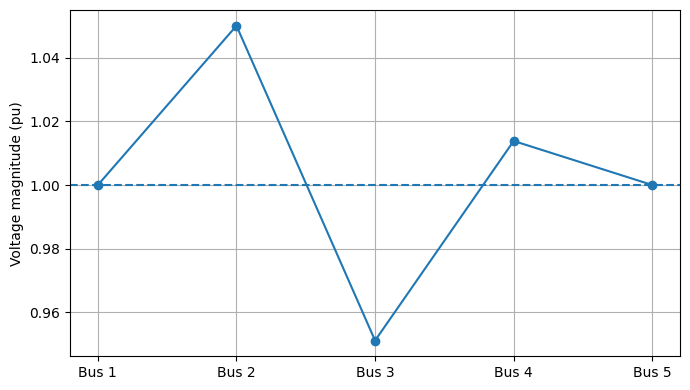

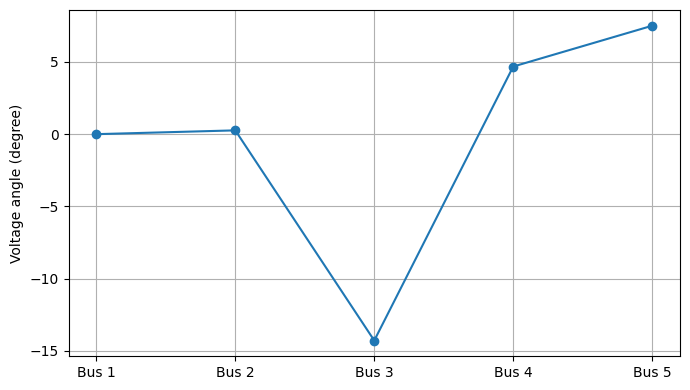

In [16]:
# Voltage magnitude plot
bus_names = net.bus["name"].tolist()
vm = net.res_bus["vm_pu"].tolist()

plt.figure(figsize=(7,4))
plt.plot(bus_names, vm, marker="o")
plt.axhline(1.0, linestyle="--")
plt.ylabel("Voltage magnitude (pu)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Voltage angle plot
angles = net.res_bus["va_degree"].tolist()

plt.figure(figsize=(7,4))
plt.plot(bus_names, angles, marker="o")
plt.ylabel("Voltage angle (degree)")
plt.grid(True)
plt.tight_layout()
plt.show()